Let us produce the simplest version of a torch SGD adam learning where the learning rate adapts.

We will calculate the gradients with backward propagation.  We will attempt to update by calling optimizer.step()

After the update has been made, we will check if a particular condition holds.  

If it holds, then we proceed.  If it fails, then we need to go back to the beginning of this step and update the parameter values with half of the learning rate.

We keep halving the learning rate until either we have done so for 10 times or we have succeeded in updating and meeting that particular condition.

Epoch 0, Loss: 1.228733777999878, Learning Rate: 0.001
Condition failed at epoch 1, halving learning rate. Attempt 1
Condition failed at epoch 1, halving learning rate. Attempt 2
Epoch 1, Loss: 1.2232494354248047, Learning Rate: 0.00025
Condition failed at epoch 2, halving learning rate. Attempt 1
Condition failed at epoch 2, halving learning rate. Attempt 2
Epoch 2, Loss: 1.2178354263305664, Learning Rate: 0.00025
Condition failed at epoch 3, halving learning rate. Attempt 1
Epoch 3, Loss: 1.2132537364959717, Learning Rate: 0.0005
Condition failed at epoch 4, halving learning rate. Attempt 1
Epoch 4, Loss: 1.2087271213531494, Learning Rate: 0.0005
Epoch 5, Loss: 1.2057405710220337, Learning Rate: 0.001
Condition failed at epoch 6, halving learning rate. Attempt 1
Epoch 6, Loss: 1.2013070583343506, Learning Rate: 0.0005
Epoch 7, Loss: 1.1983833312988281, Learning Rate: 0.001
Condition failed at epoch 8, halving learning rate. Attempt 1
Epoch 8, Loss: 1.1940438747406006, Learning Rate: 

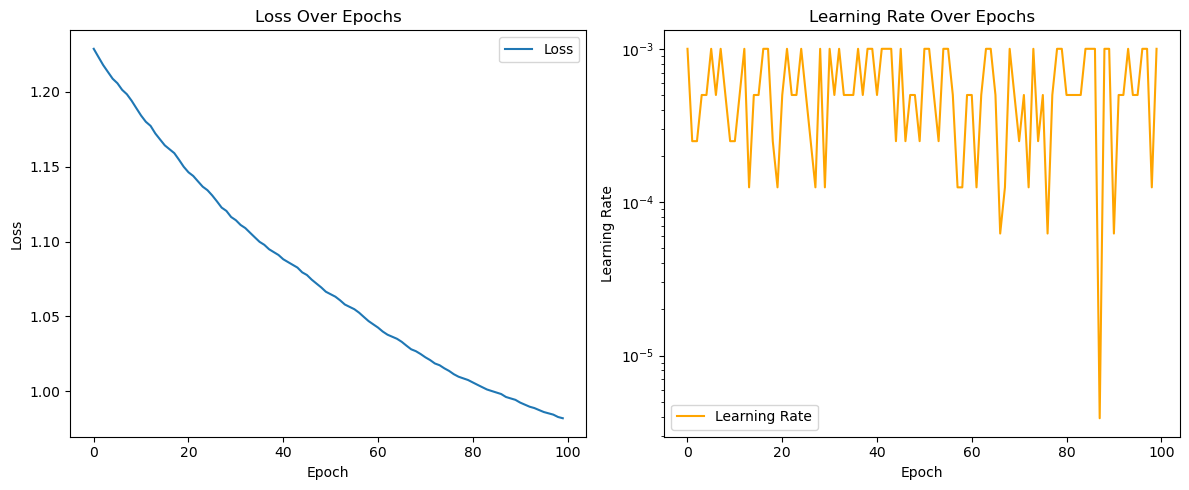


Learning Rate Halving Log:
Epoch 1: LR halved at attempt 1
Epoch 1: LR halved at attempt 2
Epoch 2: LR halved at attempt 1
Epoch 2: LR halved at attempt 2
Epoch 3: LR halved at attempt 1
Epoch 4: LR halved at attempt 1
Epoch 6: LR halved at attempt 1
Epoch 8: LR halved at attempt 1
Epoch 9: LR halved at attempt 1
Epoch 9: LR halved at attempt 2
Epoch 10: LR halved at attempt 1
Epoch 10: LR halved at attempt 2
Epoch 11: LR halved at attempt 1
Epoch 13: LR halved at attempt 1
Epoch 13: LR halved at attempt 2
Epoch 13: LR halved at attempt 3
Epoch 14: LR halved at attempt 1
Epoch 15: LR halved at attempt 1
Epoch 18: LR halved at attempt 1
Epoch 18: LR halved at attempt 2
Epoch 19: LR halved at attempt 1
Epoch 19: LR halved at attempt 2
Epoch 19: LR halved at attempt 3
Epoch 20: LR halved at attempt 1
Epoch 22: LR halved at attempt 1
Epoch 23: LR halved at attempt 1
Epoch 25: LR halved at attempt 1
Epoch 26: LR halved at attempt 1
Epoch 26: LR halved at attempt 2
Epoch 27: LR halved at at

In [15]:
import torch
import random
import torch.optim as optim
import matplotlib.pyplot as plt

# Define a simple model (a linear regression model for demonstration)
model = torch.nn.Linear(10, 1)

# Define a loss function (e.g., Mean Squared Error)
criterion = torch.nn.MSELoss()

# Optimizer: Adam
initial_lr = 0.001
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# code to recover the initial learning rate
for param_group in optimizer.param_groups:
    param_group['lr'] = initial_lr

# Example data
X = torch.randn(64, 10)  # 64 samples, 10 features each
y = torch.randn(64, 1)   # 64 targets

# Example condition: ensure loss is decreasing (customizable)
prev_loss = float('inf')

# Lists to store logging data for plotting later
loss_log = []
lr_log = []
halving_log = []

for epoch in range(100):
    
    # code to recover the initial learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = initial_lr

    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Save the current model state (before attempting the step)
    state_dict_before_step = model.state_dict()  # Save model parameters

    halving_attempts = 0
    success = False

    # Keep halving the learning rate if the condition fails, up to 10 times
    while not success and halving_attempts < 10:
        # Try optimization step
        optimizer.step()

        # Recompute the loss after the step
        with torch.no_grad():
            y_pred_after_step = model(X)
            new_loss = criterion(y_pred_after_step, y)

        # Check if the condition holds (e.g., loss should decrease)
        if random.choice([True,False]):
            success = True
        else:
            # Condition failed, revert to the previous state and halve the learning rate
            print(f"Condition failed at epoch {epoch}, halving learning rate. Attempt {halving_attempts + 1}")
            halving_log.append(f"Epoch {epoch}: LR halved at attempt {halving_attempts + 1}")
            
            # Restore model to the previous state but don't restore optimizer state
            model.load_state_dict(state_dict_before_step)

            # Halve the learning rate manually
            for param_group in optimizer.param_groups:
                param_group['lr'] /= 2

            halving_attempts += 1

    # Update the previous loss only if the step was successful
    if success:
        prev_loss = new_loss.item()
        print(f"Epoch {epoch}, Loss: {prev_loss}, Learning Rate: {optimizer.param_groups[0]['lr']}")
    else:
        print(f"Epoch {epoch} failed after 10 halving attempts, proceeding to next epoch.")

    # Log the loss and learning rate for this epoch
    loss_log.append(prev_loss)
    lr_log.append(optimizer.param_groups[0]['lr'])

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot the loss over epochs
plt.subplot(1, 2, 1)
plt.plot(loss_log, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plot the learning rate over epochs
plt.subplot(1, 2, 2)
plt.plot(lr_log, label='Learning Rate', color='orange')
plt.xlabel('Epoch')
plt.yscale("log")
plt.ylabel('Learning Rate')
plt.title('Learning Rate Over Epochs')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

# Output the halving log
print("\nLearning Rate Halving Log:")
for log in halving_log:
    print(log)


In [43]:
# These are for calculating the loss
model = torch.nn.Linear(10, 1)
criterion = torch.nn.MSELoss()

print(model.state_dict())

OrderedDict({'weight': tensor([[ 0.0792, -0.1024, -0.0620, -0.0780, -0.0215,  0.1872, -0.3026, -0.0782,
          0.1433, -0.1767]]), 'bias': tensor([0.2355])})


In [ ]:
import torch
import random
import torch.optim as optim
import matplotlib.pyplot as plt

# These are for calculating the loss
model = torch.nn.Linear(10, 1)
criterion = torch.nn.MSELoss()

# Optimizer: Adam
initial_lr = 0.001
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# code to recover the initial learning rate
for param_group in optimizer.param_groups:
                param_group['lr'] = initial_lr

# Example data
X = torch.randn(64, 10)  # 64 samples, 10 features each
y = torch.randn(64, 1)   # 64 targets

# Example condition: ensure loss is decreasing (customizable)
prev_loss = float('inf')

# Lists to store logging data for plotting later
loss_log = []
lr_log = []
halving_log = []

for epoch in range(1):
    # code to recover the initial learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = initial_lr

    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Save the current model state (before attempting the step)
    state_dict_before_step = model.state_dict()  # Save model parameters
    
    halving_attempts = 0
    success = False

    # Keep halving the learning rate if the condition fails, up to 10 times
    while not success and halving_attempts < 10:
        # Try optimization step
        optimizer.step()

        # Recompute the loss after the step
        with torch.no_grad():
            y_pred_after_step = model(X)
            new_loss = criterion(y_pred_after_step, y)

        # Check if the condition holds (e.g., loss should decrease)
        if random.choice([True,False]):
            success = True
        else:
            # Condition failed, revert to the previous state and halve the learning rate
            print(f"Condition failed at epoch {epoch}, halving learning rate. Attempt {halving_attempts + 1}")
            halving_log.append(f"Epoch {epoch}: LR halved at attempt {halving_attempts + 1}")
            
            # Restore model to the previous state but don't restore optimizer state
            model.load_state_dict(state_dict_before_step)

            # Halve the learning rate manually
            for param_group in optimizer.param_groups:
                param_group['lr'] /= 2

            halving_attempts += 1

    # Update the previous loss only if the step was successful
    if success:
        prev_loss = new_loss.item()
        print(f"Epoch {epoch}, Loss: {prev_loss}, Learning Rate: {optimizer.param_groups[0]['lr']}")
    else:
        print(f"Epoch {epoch} failed after 10 halving attempts, proceeding to next epoch.")

    # Log the loss and learning rate for this epoch
    loss_log.append(prev_loss)
    lr_log.append(optimizer.param_groups[0]['lr'])

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot the loss over epochs
plt.subplot(1, 2, 1)
plt.plot(loss_log, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plot the learning rate over epochs
plt.subplot(1, 2, 2)
plt.plot(lr_log, label='Learning Rate', color='orange')
plt.xlabel('Epoch')
plt.yscale("log")
plt.ylabel('Learning Rate')
plt.title('Learning Rate Over Epochs')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

# Output the halving log
print("\nLearning Rate Halving Log:")
for log in halving_log:
    print(log)
